1. Пять примеров применения ML в жизни и их преимущества:
   
   а) Спам-фильтр в почте - Преимущество: автоматически определяет и фильтрует 
      нежелательные письма, экономя время и повышая безопасность.
   
   б) Рекомендательные системы (Netflix, Amazon) - Преимущество: персонализируют 
      контент, увеличивая вовлеченность пользователей и продажи.
   
   в) Распознавание лиц в смартфонах - Преимущество: обеспечивает быструю и 
      безопасную аутентификацию, которую сложно подделать.
   
   г) Голосовые помощники (Siri, Алиса) - Преимущество: позволяет управлять 
      устройствами голосом, улучшая доступность и удобство.
   
   д) Диагностика заболеваний по медицинским снимкам - Преимущество: помогает 
      врачам обнаруживать заболевания раньше и точнее, снижая диагностические ошибки.

2. Классификация задач из таблицы и из примеров:
   
   Из таблицы:
   - Предсказание цены дома: Регрессия
   - Предсказание возврата кредита: Бинарная классификация
   - Время приема лекарства: Регрессия
   - Выбор лекарства: Мультиклассовая классификация
   - Сегментация клиентов: Кластеризация
   - Распознавание дефектов: Бинарная классификация
   - Размещение товаров на полке: Обучение с подкреплением
   - Поиск сайтов: Ранжирование
   - Сегментация покупателей: Кластеризация
   - Обнаружение аномалий: Поиск аномалий

3. Разница между мультиклассовой и мультиметочной классификацией:
   
   Мультиклассовая: каждый объект принадлежит ТОЛЬКО ОДНОМУ классу.
   Пример: определение вида ириса (setosa, versicolor, virginica).
   
   Мультиметочная: каждый объект может принадлежать НЕСКОЛЬКИМ классам одновременно.
   Пример: определение жанров фильма (фильм может быть одновременно "боевиком" и "комедией").

4. Цены на дома - классификация или регрессия?
   
   Предсказание цен на дома - это задача РЕГРЕССИИ, так как целевая переменная 
   (цена) является непрерывной.
   
   Да, регрессию МОЖНО свести к классификации через дискретизацию:
   - Разбить непрерывные значения на интервалы (бины)
   - Предсказывать, в какой интервал попадает значение
   - Недостаток: теряется точность, но может быть достаточно для некоторых бизнес-задач

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import scipy
import lightgbm as lgb

In [35]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [36]:
df = pd.read_json('train.json')
print(f'Shape - {df.shape}')
print(f'Columns - {df.columns}')
print(f'Target - {df['price'].name}')

Shape - (49352, 15)
Columns - Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')
Target - price


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [38]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [39]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].corr())

            bathrooms  bedrooms  latitude  listing_id  longitude     price
bathrooms    1.000000  0.533446 -0.009657    0.000776   0.010393  0.069661
bedrooms     0.533446  1.000000 -0.004745    0.011968   0.006892  0.051788
latitude    -0.009657 -0.004745  1.000000    0.001712  -0.966807 -0.000707
listing_id   0.000776  0.011968  0.001712    1.000000  -0.000907  0.008090
longitude    0.010393  0.006892 -0.966807   -0.000907   1.000000 -0.000087
price        0.069661  0.051788 -0.000707    0.008090  -0.000087  1.000000


In [40]:
empty_cols = df.columns[df.isnull().all()].tolist()
empty_cols

[]

In [41]:
df_selected = df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()

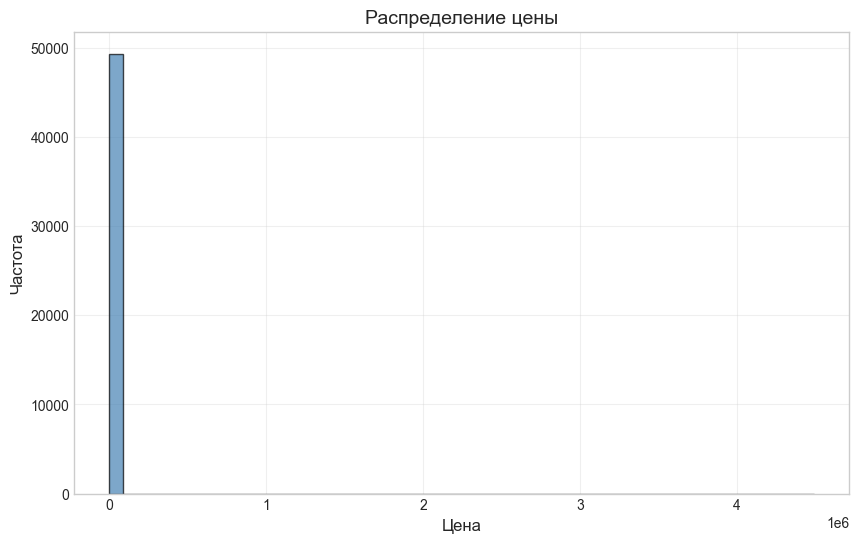

Минимум: 43.00
Максимум: 4490000.00
Среднее: 3830.17
Медиана: 3150.00
Стандартное отклонение: 22066.87


In [42]:
plt.figure(figsize=(10, 6))
plt.hist(df_selected['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Распределение цены', fontsize=14)
plt.xlabel('Цена', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Минимум: {df_selected['price'].min():.2f}")
print(f"Максимум: {df_selected['price'].max():.2f}")
print(f"Среднее: {df_selected['price'].mean():.2f}")
print(f"Медиана: {df_selected['price'].median():.2f}")
print(f"Стандартное отклонение: {df_selected['price'].std():.2f}")

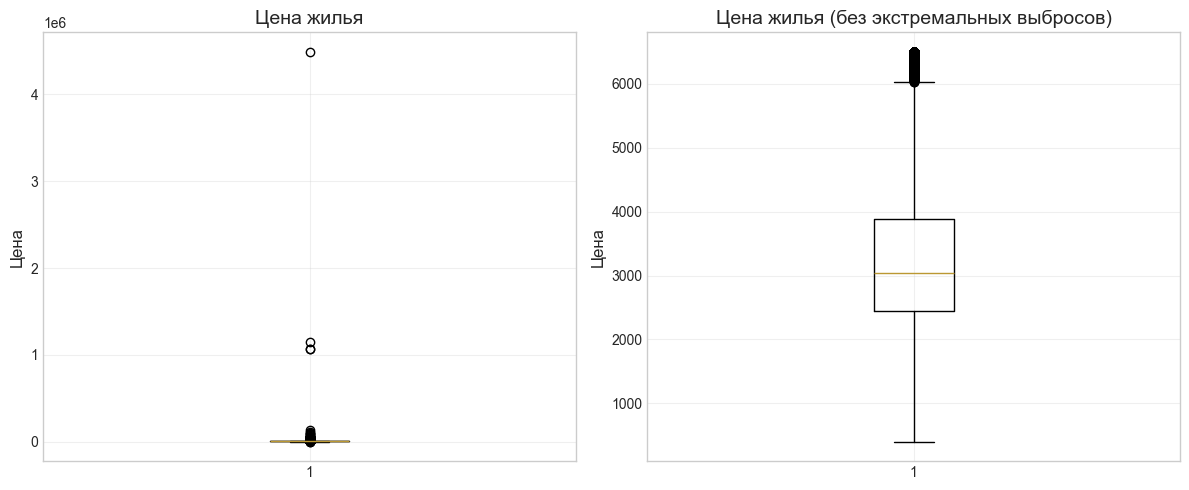

Количество выбросов по IQR методу: 2788
Процент выбросов: 5.65%


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df_selected['price'])
axes[0].set_title('Цена жилья', fontsize=14)
axes[0].set_ylabel('Цена', fontsize=12)
axes[0].grid(True, alpha=0.3)

Q1 = df_selected['price'].quantile(0.25)
Q3 = df_selected['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_no_outliers = df_selected[(df_selected['price'] >= lower_bound) & 
                              (df_selected['price'] <= upper_bound)]

axes[1].boxplot(df_no_outliers['price'])
axes[1].set_title('Цена жилья (без экстремальных выбросов)', fontsize=14)
axes[1].set_ylabel('Цена', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Количество выбросов по IQR методу: {len(df_selected) - len(df_no_outliers)}")
print(f"Процент выбросов: {(1 - len(df_no_outliers)/len(df_selected))*100:.2f}%")

In [44]:
percentile_1 = df_selected['price'].quantile(0.01)
percentile_99 = df_selected['price'].quantile(0.99)
df_clean = df_selected[(df_selected['price'] >= percentile_1) & 
                        (df_selected['price'] <= percentile_99)].copy()


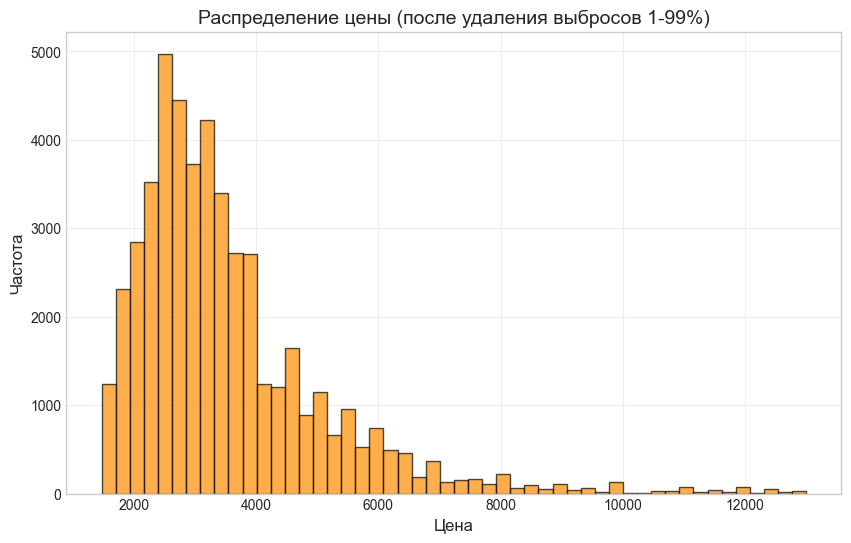

После удаления выбросов распределение стало более нормальным
Минимум: 1475.00
Максимум: 13000.00


In [45]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean['price'], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
plt.title('Распределение цены (после удаления выбросов 1-99%)', fontsize=14)
plt.xlabel('Цена', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("После удаления выбросов распределение стало более нормальным")
print(f"Минимум: {df_clean['price'].min():.2f}")
print(f"Максимум: {df_clean['price'].max():.2f}")

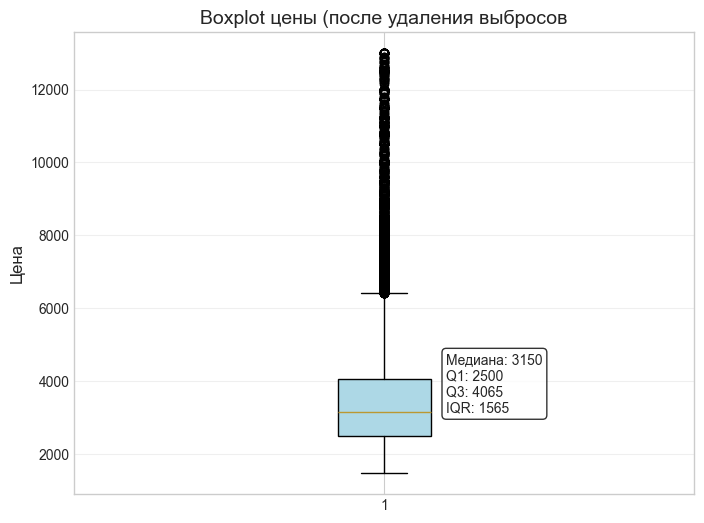

In [46]:
plt.figure(figsize=(8, 6))
box = plt.boxplot(df_clean['price'], patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
plt.title('Boxplot цены (после удаления выбросов', fontsize=14)
plt.ylabel('Цена', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

stats_text = f"Медиана: {df_clean['price'].median():.0f}\n"
stats_text += f"Q1: {df_clean['price'].quantile(0.25):.0f}\n"
stats_text += f"Q3: {df_clean['price'].quantile(0.75):.0f}\n"
stats_text += f"IQR: {df_clean['price'].quantile(0.75) - df_clean['price'].quantile(0.25):.0f}"
plt.text(1.1, df_clean['price'].median(), stats_text, fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.show()

In [47]:
print(f"Тип колонки 'interest_level': {df_clean['interest_level'].dtype}")

encoding_map = {'high': 2, 'medium': 1, 'low': 0}
df_clean['interest_level_encoded'] = df_clean['interest_level'].map(encoding_map)
print(df_clean['interest_level_encoded'].value_counts())

Тип колонки 'interest_level': object
interest_level_encoded
0    33697
1    11116
2     3566
Name: count, dtype: int64


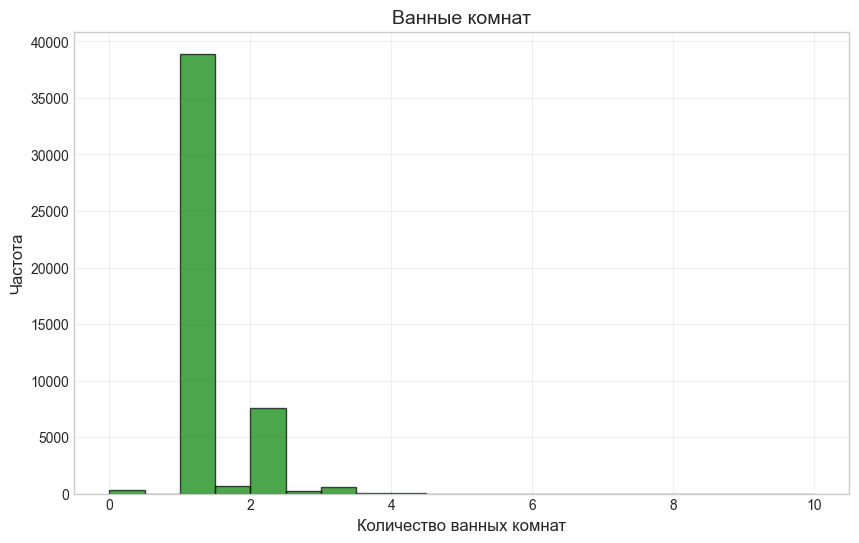

In [48]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean['bathrooms'], bins=20, edgecolor='black', alpha=0.7, color='green')
plt.title('Ванные комнат', fontsize=14)
plt.xlabel('Количество ванных комнат', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

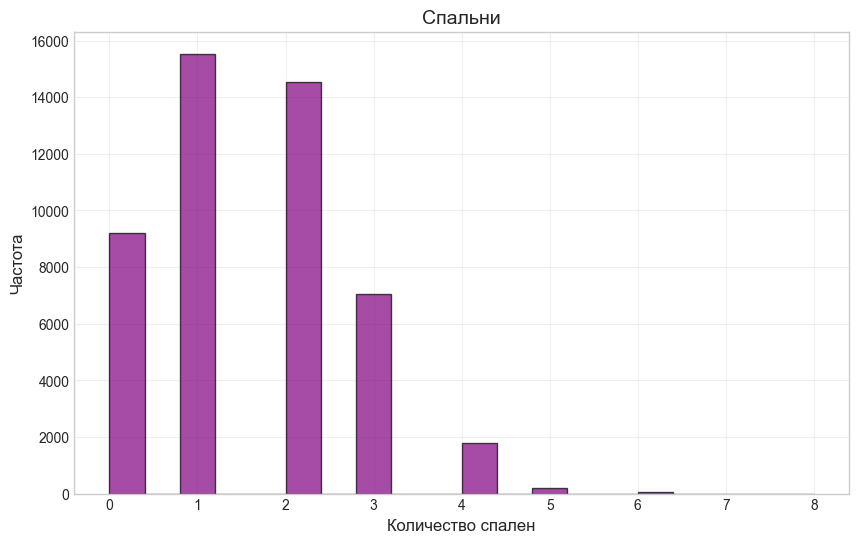

In [49]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean['bedrooms'], bins=20, edgecolor='black', alpha=0.7, color='purple')
plt.title('Спальни', fontsize=14)
plt.xlabel('Количество спален', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
for col in ['bathrooms', 'bedrooms']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    print(f"{col}: {len(outliers)} выбросов ({(len(outliers)/len(df_clean))*100:.2f}%)")

bathrooms: 9451 выбросов (19.54%)
bedrooms: 2031 выбросов (4.20%)


Корреляционная матрица:
                        bathrooms  bedrooms  interest_level_encoded     price
bathrooms                1.000000  0.517574               -0.063635  0.671943
bedrooms                 0.517574  1.000000                0.050654  0.545948
interest_level_encoded  -0.063635  0.050654                1.000000 -0.200111
price                    0.671943  0.545948               -0.200111  1.000000


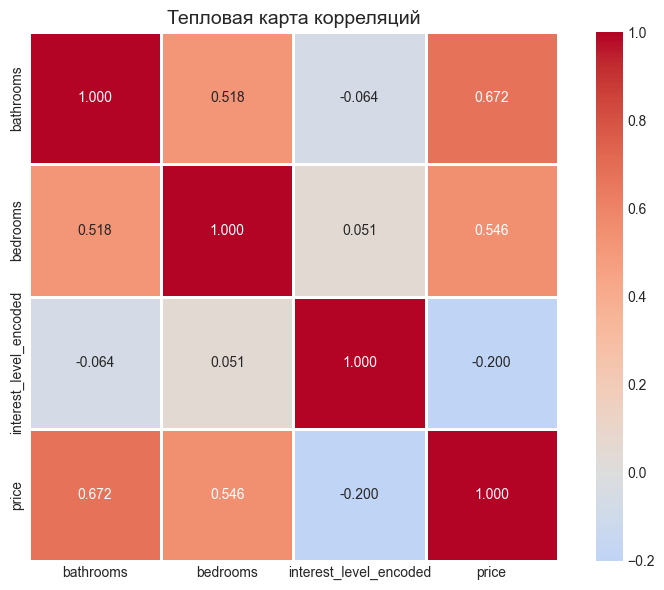

In [51]:
numeric_features = ['bathrooms', 'bedrooms', 'interest_level_encoded', 'price']
corr_matrix = df_clean[numeric_features].corr()

print("Корреляционная матрица:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', linewidths=1)
plt.title('Тепловая карта корреляций', fontsize=14)
plt.tight_layout()
plt.show()

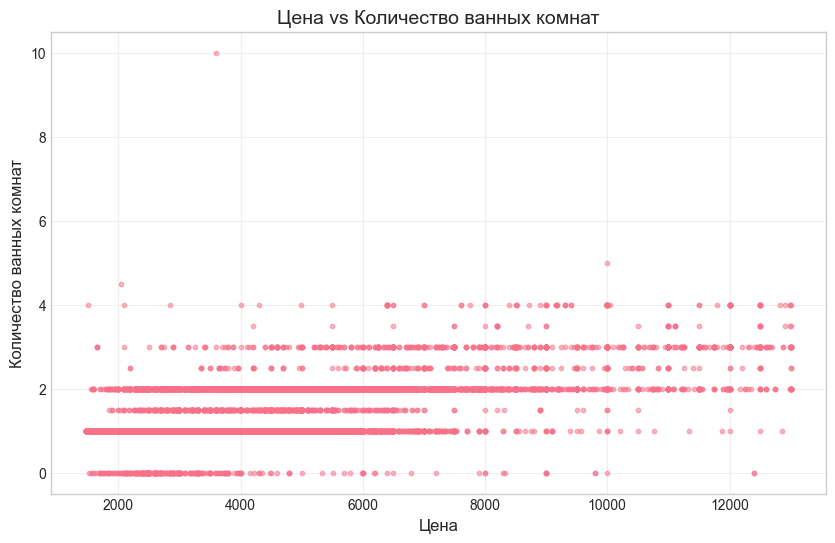

In [52]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['price'], df_clean['bathrooms'], alpha=0.5, s=10)
plt.xlabel('Цена', fontsize=12)
plt.ylabel('Количество ванных комнат', fontsize=12)
plt.title('Цена vs Количество ванных комнат', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

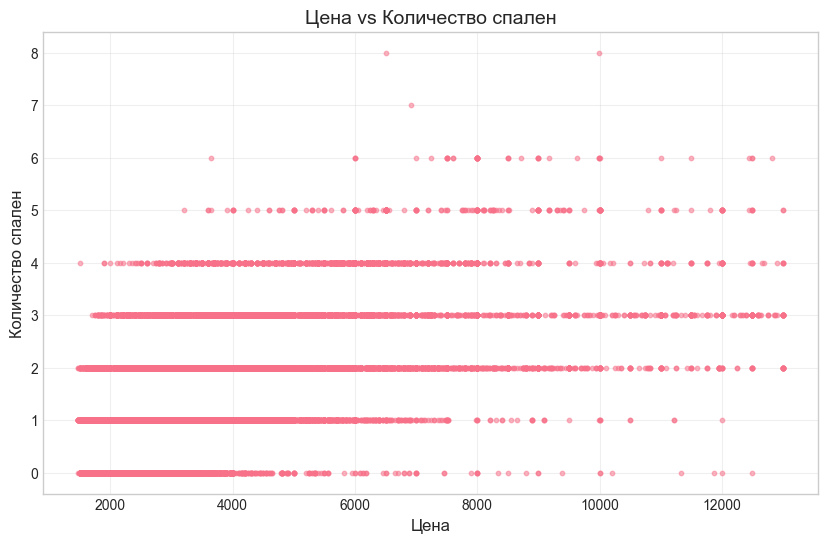

In [53]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['price'], df_clean['bedrooms'], alpha=0.5, s=10)
plt.xlabel('Цена', fontsize=12)
plt.ylabel('Количество спален', fontsize=12)
plt.title('Цена vs Количество спален', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

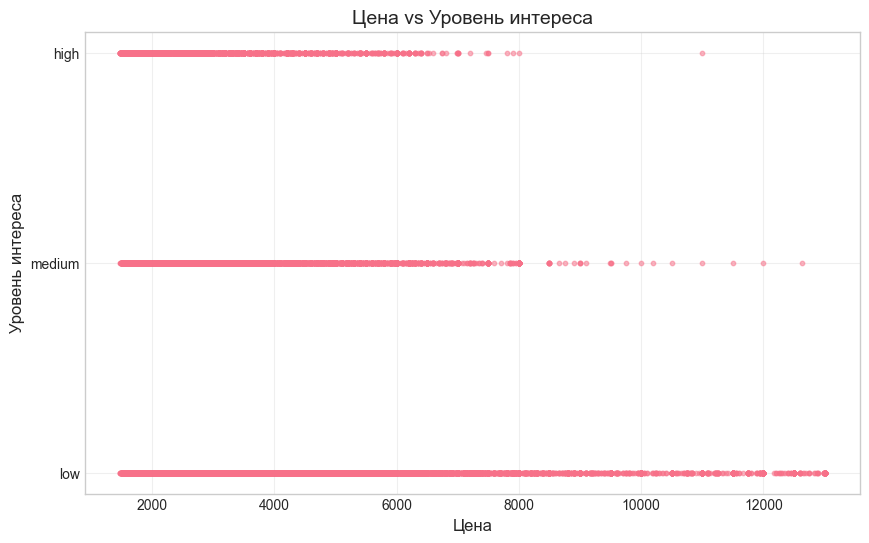

In [54]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['price'], df_clean['interest_level_encoded'], alpha=0.5, s=10)
plt.xlabel('Цена', fontsize=12)
plt.ylabel('Уровень интереса', fontsize=12)
plt.title('Цена vs Уровень интереса', fontsize=14)
plt.yticks([0, 1, 2], ['low', 'medium', 'high'])
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
df_clean['bathrooms_squared'] = df_clean['bathrooms'] ** 2
df_clean['bedrooms_squared'] = df_clean['bedrooms'] ** 2
df_clean['interest_level_squared'] = df_clean['interest_level_encoded'] ** 2
df_clean.head()

,bathrooms,bedrooms,interest_level,price,interest_level_encoded,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,medium,2400,1,1.00,1,1
6,1.0,2,low,3800,0,1.00,4,0
9,1.0,2,medium,3495,1,1.00,4,1
10,1.5,3,medium,3000,1,2.25,9,1
15,1.0,0,low,2795,0,1.00,0,0


In [56]:
all_numeric = ['bathrooms', 'bedrooms', 'interest_level_encoded', 
               'bathrooms_squared', 'bedrooms_squared', 
               'interest_level_squared', 'price']
new_corr_matrix = df_clean[all_numeric].corr()

print("Корреляция с price:")
corr_with_target = new_corr_matrix['price'].sort_values(ascending=False)
for feature, corr_val in corr_with_target.items():
    print(f"{feature}: {corr_val:.4f}")

Корреляция с price:
price: 1.0000
bathrooms: 0.6719
bathrooms_squared: 0.6485
bedrooms: 0.5459
bedrooms_squared: 0.5434
interest_level_squared: -0.1827
interest_level_encoded: -0.2001


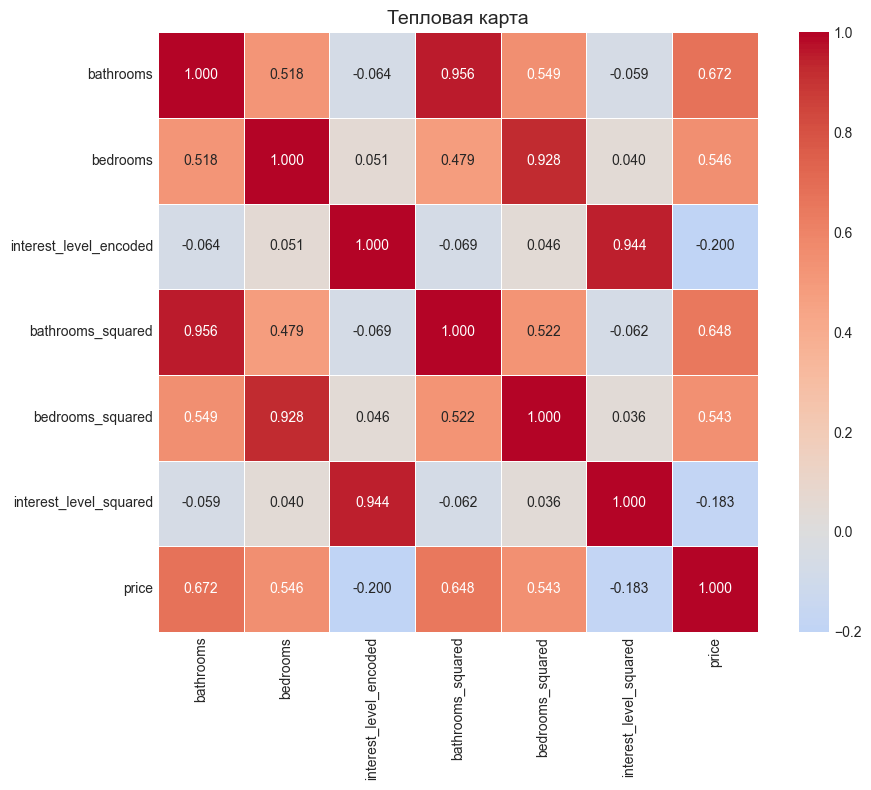

In [57]:
plt.figure(figsize=(10, 8))
sns.heatmap(new_corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', linewidths=0.5)
plt.title('Тепловая карта', fontsize=14)
plt.tight_layout()
plt.show()

In [58]:
X = df_clean[['bathrooms', 'bedrooms']].values
y = df_clean['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [59]:
poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

In [60]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [61]:
lr_model = LinearRegression()
lr_model.fit(X_train_poly, y_train)

y_train_pred_lr = lr_model.predict(X_train_poly)
y_test_pred_lr = lr_model.predict(X_test_poly)

train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print(f"Линейная регрессия:")
print(f"MAE - Train: {train_mae_lr:.2f}")
print(f"MAE - Test: {test_mae_lr:.2f}")
print(f"RMSE - Train: {train_rmse_lr:.2f}")
print(f"RMSE - Test: {test_rmse_lr:.2f}")

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['linear_regression'],
    'train': [train_mae_lr],
    'test': [test_mae_lr]
})], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['linear_regression'],
    'train': [train_rmse_lr],
    'test': [test_rmse_lr]
})], ignore_index=True)

Линейная регрессия:
MAE - Train: 756.73
MAE - Test: 759.83
RMSE - Train: 1079.07
RMSE - Test: 1247.30


/var/folders/sn/y3sl6hf53sq05xycssj677qc0000gn/T/ipykernel_5282/665778923.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_MAE = pd.concat([result_MAE, pd.DataFrame({
/var/folders/sn/y3sl6hf53sq05xycssj677qc0000gn/T/ipykernel_5282/665778923.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_RMSE = pd.concat([result_RMSE, pd.DataFrame({


In [62]:
dt_model = DecisionTreeRegressor(random_state=21)
dt_model.fit(X_train_poly, y_train)

y_train_pred_dt = dt_model.predict(X_train_poly)
y_test_pred_dt = dt_model.predict(X_test_poly)

train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)
test_mae_dt = mean_absolute_error(y_test, y_test_pred_dt)
train_rmse_dt = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))
test_rmse_dt = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))

print(f"Дерево решений:")
print(f"MAE - Train: {train_mae_dt:.2f}")
print(f"MAE - Test: {test_mae_dt:.2f}")
print(f"RMSE - Train: {train_rmse_dt:.2f}")
print(f"RMSE - Test: {test_rmse_dt:.2f}")

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['decision_tree'],
    'train': [train_mae_dt],
    'test': [test_mae_dt]
})], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['decision_tree'],
    'train': [train_rmse_dt],
    'test': [test_rmse_dt]
})], ignore_index=True)

Дерево решений:
MAE - Train: 756.70
MAE - Test: 754.05
RMSE - Train: 1078.97
RMSE - Test: 1074.05


In [63]:
train_mean = np.mean(y_train)
train_median = np.median(y_train)

y_train_pred_mean = np.full_like(y_train, train_mean)
y_test_pred_mean = np.full_like(y_test, train_mean)

train_mae_mean = mean_absolute_error(y_train, y_train_pred_mean)
test_mae_mean = mean_absolute_error(y_test, y_test_pred_mean)
train_rmse_mean = np.sqrt(mean_squared_error(y_train, y_train_pred_mean))
test_rmse_mean = np.sqrt(mean_squared_error(y_test, y_test_pred_mean))

print(f"\nNaive Mean:")
print(f"MAE - Train: {train_mae_mean:.2f}")
print(f"MAE - Test: {test_mae_mean:.2f}")
print(f"RMSE - Train: {train_rmse_mean:.2f}")
print(f"RMSE - Test: {test_rmse_mean:.2f}")

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['naive_mean'],
    'train': [train_mae_mean],
    'test': [test_mae_mean]
})], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['naive_mean'],
    'train': [train_rmse_mean],
    'test': [test_rmse_mean]
})], ignore_index=True)

y_train_pred_median = np.full_like(y_train, train_median)
y_test_pred_median = np.full_like(y_test, train_median)

train_mae_median = mean_absolute_error(y_train, y_train_pred_median)
test_mae_median = mean_absolute_error(y_test, y_test_pred_median)
train_rmse_median = np.sqrt(mean_squared_error(y_train, y_train_pred_median))
test_rmse_median = np.sqrt(mean_squared_error(y_test, y_test_pred_median))

print(f"\nNaive Median:")
print(f"MAE - Train: {train_mae_median:.2f}")
print(f"MAE - Test: {test_mae_median:.2f}")
print(f"RMSE - Train: {train_rmse_median:.2f}")
print(f"RMSE - Test: {test_rmse_median:.2f}")

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['naive_median'],
    'train': [train_mae_median],
    'test': [test_mae_median]
})], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['naive_median'],
    'train': [train_rmse_median],
    'test': [test_rmse_median]
})], ignore_index=True)


Naive Mean:
MAE - Train: 1140.32
MAE - Test: 1136.50
RMSE - Train: 1598.46
RMSE - Test: 1594.39

Naive Median:
MAE - Train: 1087.46
MAE - Test: 1081.22
RMSE - Train: 1645.46
RMSE - Test: 1639.34


In [64]:
best_mae_model = result_MAE.loc[result_MAE['test'].idxmin(), 'model']
best_mae_score = result_MAE['test'].min()
print(f"\nЛучшая модель по MAE на тестовой выборке: {best_mae_model} (MAE = {best_mae_score:.2f})")

best_rmse_model = result_RMSE.loc[result_RMSE['test'].idxmin(), 'model']
best_rmse_score = result_RMSE['test'].min()
print(f"Лучшая модель по RMSE на тестовой выборке: {best_rmse_model} (RMSE = {best_rmse_score:.2f})")


Лучшая модель по MAE на тестовой выборке: decision_tree (MAE = 754.05)
Лучшая модель по RMSE на тестовой выборке: decision_tree (RMSE = 1074.05)


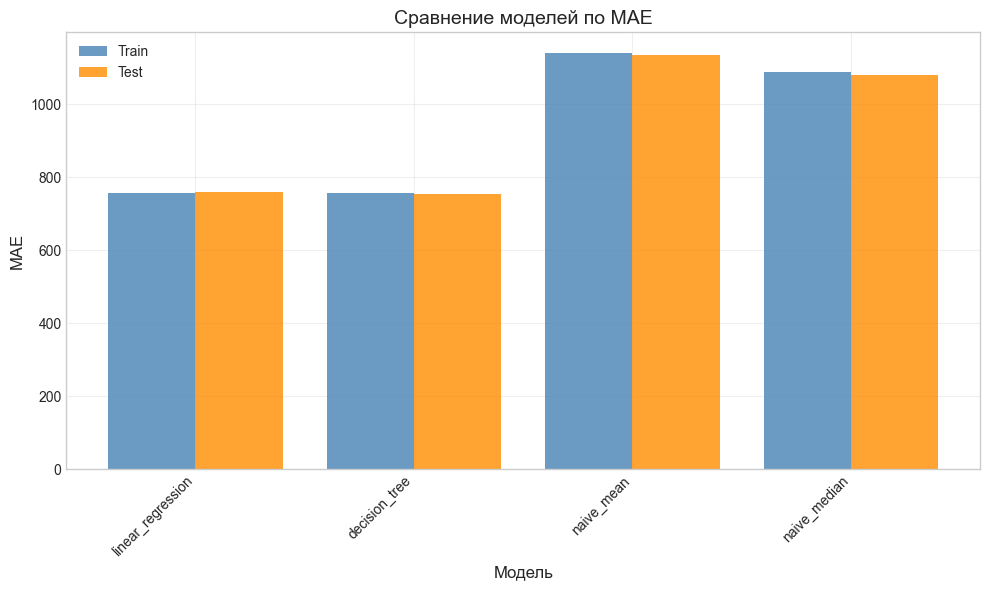

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(result_MAE))

ax.bar(x, result_MAE['train'], width=0.4, label='Train', alpha=0.8, color='steelblue')
ax.bar([i + 0.4 for i in x], result_MAE['test'], width=0.4, label='Test', alpha=0.8, color='darkorange')
ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Сравнение моделей по MAE', fontsize=14)
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(result_MAE['model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

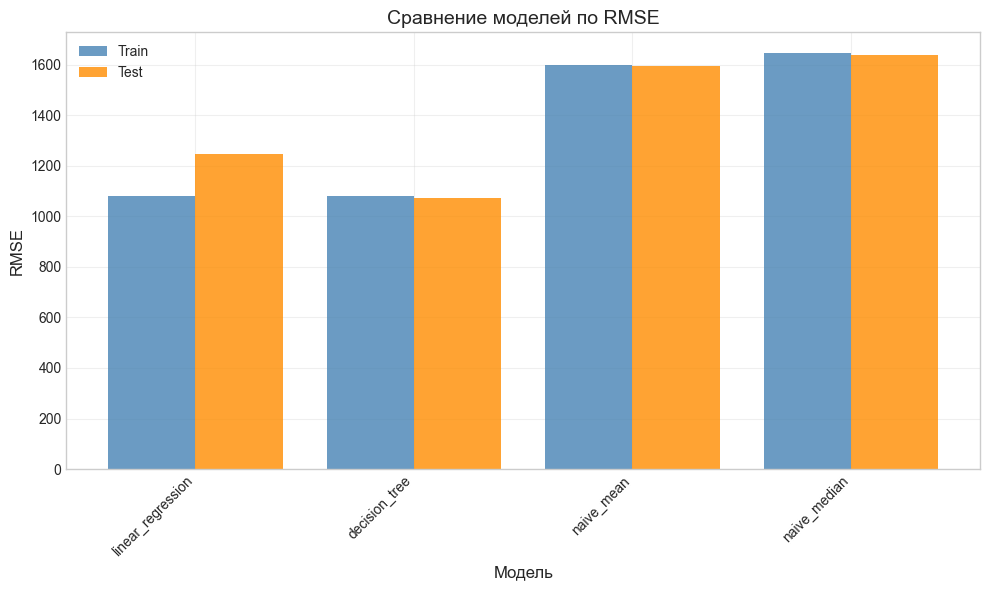

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(result_RMSE))

ax.bar(x, result_RMSE['train'], width=0.4, label='Train', alpha=0.8, color='steelblue')
ax.bar([i + 0.4 for i in x], result_RMSE['test'], width=0.4, label='Test', alpha=0.8, color='darkorange')
ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Сравнение моделей по RMSE', fontsize=14)
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(result_RMSE['model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()